# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Проверка гипотезы о различии пользовательской активности в сервисе Яндекс     Книги

- Автор: Екатерина Мирау
- Дата: 16.05.2026

## Цели и задачи проекта

Цель — проверить гипотезу о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении Яндекс Книги, чем пользователи из Москвы.

Задачи:
- загрузить и проверить данные на дубликаты
- сравнить размеры групп и их описательные статистики
- провести одностороннюю проверку гипотезы с помощью t-теста
- интерпретировать результаты и сформулировать выводы

## Описание данных

Данные получены из сервиса Яндекс Книги за период с 1 сентября по 11 декабря 2024 года. Для анализа используется файл `yandex_knigi_data.csv`, подготовленный на этапе предобработки в SQL.

Файл содержит агрегированные данные по пользователям из Москвы и Санкт-Петербурга:
- `puid` — идентификатор пользователя
- `city` — город пользователя (Москва или Санкт-Петербург)
- `hours` — суммарное время активности пользователя в часах

## Содержимое проекта

1. Загрузка данных
2. Проверка дубликатов в идентификаторах пользователей
3. Сравнение групп: размер, описательные статистики, распределение
4. Проверка гипотезы: односторонний двухвыборочный t-тест
5. Аналитическая записка: интерпретация результатов
---

## Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/datasets/yandex_knigi_data.csv', index_col=0)

print('Первые строки:')
print(df.head())

print('\nРазмер датафрейма:', df.shape)
print('\nНазвания столбцов:', df.columns.tolist())
print('\nТипы данных:')
print(df.dtypes)

Первые строки:
     city    puid       hours
0  Москва    9668   26.167776
1  Москва   16598   82.111217
2  Москва   80401    4.656906
3  Москва  140205    1.840556
4  Москва  248755  151.326434

Размер датафрейма: (8784, 3)

Названия столбцов: ['city', 'puid', 'hours']

Типы данных:
city      object
puid       int64
hours    float64
dtype: object


In [3]:
# Проверяем дубликаты по идентификатору пользователя
print('Количество дубликатов по puid:', df['puid'].duplicated().sum())

# Смотрим размер каждой группы
print('\nРазмер групп:')
print(df['city'].value_counts())

# Описательные статистики по часам в разрезе городов
print('\nСтатистики по группам:')
print(df.groupby('city')['hours'].describe())

Количество дубликатов по puid: 244

Размер групп:
Москва             6234
Санкт-Петербург    2550
Name: city, dtype: int64

Статистики по группам:
                  count       mean        std       min       25%       50%  \
city                                                                          
Москва           6234.0  10.881092  36.851683  0.000018  0.059903  0.924498   
Санкт-Петербург  2550.0  11.592691  39.704993  0.000025  0.080002  0.984781   

                      75%         max  
city                                   
Москва           5.939972  857.209373  
Санкт-Петербург  6.509072  978.764775  


In [4]:
# Удаляем дубликаты по puid — оставляем первую запись
df = df.drop_duplicates(subset='puid')

print('Размер после удаления дубликатов:', df.shape)
print('\nРазмер групп после очистки:')
print(df['city'].value_counts())

print('\nСтатистики по группам после очистки:')
print(df.groupby('city')['hours'].describe())

Размер после удаления дубликатов: (8540, 3)

Размер групп после очистки:
Москва             6234
Санкт-Петербург    2306
Name: city, dtype: int64

Статистики по группам после очистки:
                  count       mean        std       min       25%       50%  \
city                                                                          
Москва           6234.0  10.881092  36.851683  0.000018  0.059903  0.924498   
Санкт-Петербург  2306.0  11.264433  39.831755  0.000025  0.060173  0.875355   

                      75%         max  
city                                   
Москва           5.939972  857.209373  
Санкт-Петербург  6.138424  978.764775  


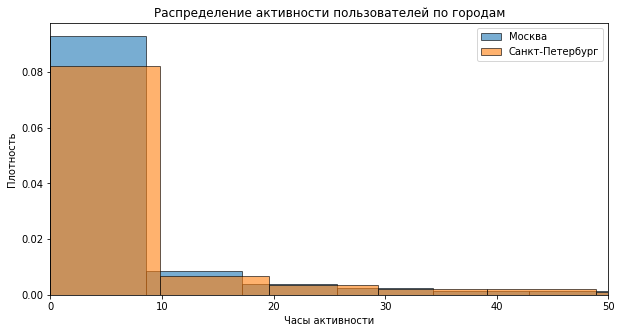

In [5]:
msk = df[df['city'] == 'Москва']['hours']
spb = df[df['city'] == 'Санкт-Петербург']['hours']

plt.figure(figsize=(10, 5))
plt.hist(msk, bins=100, alpha=0.6, label='Москва', edgecolor='black', density=True)
plt.hist(spb, bins=100, alpha=0.6, label='Санкт-Петербург', edgecolor='black', density=True)
plt.xlim(0, 50)
plt.xlabel('Часы активности')
plt.ylabel('Плотность')
plt.title('Распределение активности пользователей по городам')
plt.legend()
plt.show()

Оба распределения правосторонне скошены: большинство пользователей
проводит в приложении менее 10 часов, у небольшой доли — значительно больше.
Форма распределений в обеих группах схожа, заметных визуальных различий нет.

## Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [6]:
# Разделяем данные на две группы
spb = df[df['city'] == 'Санкт-Петербург']['hours']
msk = df[df['city'] == 'Москва']['hours']

# Используем односторонний двухвыборочный t-тест
# alternative='greater' означает: проверяем, что среднее СПб > среднего Москвы
# Уровень значимости alpha = 0.05
t_stat, p_value = stats.ttest_ind(spb, msk, alternative='greater')

print(f'T-статистика: {t_stat:.4f}')
print(f'P-value: {p_value:.4f}')

if p_value < 0.05:
    print('\nНулевая гипотеза отвергается.')
    print('Активность пользователей в Санкт-Петербурге статистически значимо выше, чем в Москве.')
else:
    print('\nНулевая гипотеза не отвергается.')
    print('Статистически значимого различия между группами не обнаружено.')

T-статистика: 0.4174
P-value: 0.3382

Нулевая гипотеза не отвергается.
Статистически значимого различия между группами не обнаружено.


## Аналитическая записка


**Тип теста и уровень значимости**

Для проверки гипотезы использовался односторонний двухвыборочный t-тест (`ttest_ind` с параметром `alternative='greater'`). Он подходит в данном случае, потому что нас интересует конкретное направление различия: активность в Санкт-Петербурге **больше**, чем в Москве, а не просто отличается.

Уровень статистической значимости: **α = 0.05**.

Перед проведением теста из данных были удалены дубликаты по идентификатору пользователя (244 записи). Итоговый размер выборок: Москва — 6 234 пользователя, Санкт-Петербург — 2 306 пользователей.

---

**Результат теста**

- T-статистика: **0.4174**
- P-value: **0.3382**

---

**Вывод**

P-value (0.3382) значительно превышает уровень значимости 0.05. Это означает, что **нулевая гипотеза не отвергается**: статистически значимого различия между средним временем активности пользователей Санкт-Петербурга и Москвы не обнаружено.

Несмотря на то что среднее значение часов в Санкт-Петербурге немного выше (11.26 ч против 10.88 ч в Москве), это различие могло возникнуть случайно и не является статистически значимым.

---

**Возможные причины результата**

1. **Различие есть, но данных недостаточно, чтобы его зафиксировать.** Выборка Санкт-Петербурга почти в 2.7 раза меньше московской (2 306 против 6 234). При высоком разбросе значений (std около 39–40 часов) небольшое различие в средних сложно выявить статистически.

2. **Гипотеза об активности не подтверждается данными.** Более высокий LTV петербургских пользователей может объясняться другими факторами — например, тарифными планами или структурой подписок — а не большим временем, проведённым в приложении.


----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## Опишите цели исследования.



Цель — оценить результаты A/B-теста интернет-магазина BitMotion Kit и определить, стоит ли внедрять новую версию сайта для всех пользователей.

В рамках теста `interface_eu_test` часть пользователей работала со старым интерфейсом (группа A, контрольная), другая часть — с новым упрощённым (группа B). Гипотеза: новый интерфейс увеличит конверсию зарегистрированных пользователей в покупателей минимум на 3 процентных пункта в течение 7 дней после регистрации.

Задачи:
- загрузить данные об участниках теста и их событиях
- проверить корректность проведения теста
- рассчитать конверсию в покупку для групп A и B
- оценить статистическую значимость различий между группами
- сформулировать вывод и рекомендацию

## Загрузите данные, оцените их целостность.


In [7]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [8]:
print('=== Таблица participants ===')
print(participants.head())
print('\nРазмер:', participants.shape)
print('\nТипы данных:')
print(participants.dtypes)
print('\nПропуски:')
print(participants.isnull().sum())
print('\nУникальные тесты:', participants['ab_test'].unique())
print('\nГруппы:', participants['group'].unique())

print('\n=== Таблица events ===')
print(events.head())
print('\nРазмер:', events.shape)
print('\nТипы данных:')
print(events.dtypes)
print('\nПропуски:')
print(events.isnull().sum())
print('\nТипы событий:')
print(events['event_name'].value_counts())

=== Таблица participants ===
            user_id group                  ab_test   device
0  0002CE61FF2C4011     B        interface_eu_test      Mac
1  001064FEAAB631A1     B  recommender_system_test  Android
2  001064FEAAB631A1     A        interface_eu_test  Android
3  0010A1C096941592     A  recommender_system_test  Android
4  001E72F50D1C48FA     A        interface_eu_test      Mac

Размер: (14525, 4)

Типы данных:
user_id    object
group      object
ab_test    object
device     object
dtype: object

Пропуски:
user_id    0
group      0
ab_test    0
device     0
dtype: int64

Уникальные тесты: ['interface_eu_test' 'recommender_system_test']

Группы: ['B' 'A']

=== Таблица events ===
            user_id            event_dt                        event_name  \
0            GLOBAL 2020-12-01 00:00:00  End of Black Friday Ads Campaign   
1  CCBE9E7E99F94A08 2020-12-01 00:00:11                      registration   
2            GLOBAL 2020-12-01 00:00:25                      product_page 

## По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [9]:
# Выделяем только участников нашего теста
test_participants = participants[participants['ab_test'] == 'interface_eu_test']

print('Участников в тесте interface_eu_test:', len(test_participants))

print('\nРаспределение по группам (количество):')
print(test_participants['group'].value_counts())

print('\nДоля групп:')
print(test_participants['group'].value_counts(normalize=True).round(3))

# Проверяем пересечения с конкурирующим тестом
# Пользователи, которые одновременно участвуют в recommender_system_test
recommender_users = participants[participants['ab_test'] == 'recommender_system_test']['user_id']
crossed_users = test_participants[test_participants['user_id'].isin(recommender_users)]
print(f'\nПользователей, участвующих одновременно в двух тестах: {len(crossed_users)}')

Участников в тесте interface_eu_test: 10850

Распределение по группам (количество):
B    5467
A    5383
Name: group, dtype: int64

Доля групп:
B    0.504
A    0.496
Name: group, dtype: float64

Пользователей, участвующих одновременно в двух тестах: 887


3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [10]:
# Убираем пользователей с пересечением тестов
clean_participants = test_participants[
    ~test_participants['user_id'].isin(crossed_users['user_id'])
]
print('Участников после исключения пересечений:', len(clean_participants))

# Список чистых user_id
test_user_ids = clean_participants['user_id'].unique()

# Фильтруем события: только участники теста и без GLOBAL
test_events = events[
    (events['user_id'].isin(test_user_ids)) &
    (events['user_id'] != 'GLOBAL')
].copy()

print('Событий для участников теста:', len(test_events))
print('Уникальных пользователей в событиях:', test_events['user_id'].nunique())

Участников после исключения пересечений: 9963
Событий для участников теста: 73815
Уникальных пользователей в событиях: 9963


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [11]:
# Берём дату регистрации из события 'registration'
registration_dates = (
    test_events[test_events['event_name'] == 'registration']
    .groupby('user_id')['event_dt']
    .min()
    .reset_index()
)
registration_dates.columns = ['user_id', 'registration_dt']

print('Пользователей с событием registration:', len(registration_dates))

# Присоединяем дату регистрации к событиям
test_events = test_events.merge(registration_dates, on='user_id', how='inner')

# Считаем дни с момента регистрации
test_events['days_after_reg'] = (
    test_events['event_dt'] - test_events['registration_dt']
).dt.days

# Оставляем только первые 7 дней
test_events_7d = test_events[test_events['days_after_reg'] <= 7]

print('Событий в первые 7 дней:', len(test_events_7d))
print('Уникальных пользователей:', test_events_7d['user_id'].nunique())

Пользователей с событием registration: 9963
Событий в первые 7 дней: 65725
Уникальных пользователей: 9963


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [12]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Параметры из ТЗ:
# Базовый CR = 30%, минимальный прирост = 3пп → целевой CR = 33%
# Мощность 80%, уровень значимости 5%

base_cr = 0.30
target_cr = 0.33

effect = proportion_effectsize(base_cr, target_cr)
analysis = NormalIndPower()
required_n = analysis.solve_power(
    effect_size=effect,
    power=0.80,
    alpha=0.05,
    alternative='two-sided'
)

print(f'Необходимый размер каждой группы: {int(required_n) + 1}')
print(f'Фактический размер группы A: {len(clean_participants[clean_participants["group"] == "A"])}')
print(f'Фактический размер группы B: {len(clean_participants[clean_participants["group"] == "B"])}')

Необходимый размер каждой группы: 3762
Фактический размер группы A: 4952
Фактический размер группы B: 5011


- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [13]:
# Все чистые участники с группами
all_users = clean_participants[['user_id', 'group']].copy()

# Пользователи, совершившие покупку в первые 7 дней
buyers_7d = (
    test_events_7d[test_events_7d['event_name'] == 'purchase'][['user_id']]
    .drop_duplicates()
)
buyers_7d['purchased'] = 1

# Объединяем
all_users = all_users.merge(buyers_7d, on='user_id', how='left')
all_users['purchased'] = all_users['purchased'].fillna(0)

# Конверсия по группам
conversion = all_users.groupby('group').agg(
    total=('user_id', 'count'),
    buyers=('purchased', 'sum')
).reset_index()

conversion['conversion_rate'] = (conversion['buyers'] / conversion['total']).round(4)
print(conversion)

cr_a = conversion[conversion['group'] == 'A']['conversion_rate'].values[0]
cr_b = conversion[conversion['group'] == 'B']['conversion_rate'].values[0]

abs_uplift = cr_b - cr_a
rel_uplift = (cr_b - cr_a) / cr_a * 100

print(f'\nАбсолютный прирост конверсии: {abs_uplift*100:.2f} п.п.')
print(f'Относительный прирост конверсии: {rel_uplift:.2f}%')

  group  total  buyers  conversion_rate
0     A   4952  1435.0           0.2898
1     B   5011  1562.0           0.3117

Абсолютный прирост конверсии: 2.19 п.п.
Относительный прирост конверсии: 7.56%


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

**Предварительный вывод**

Размер обеих групп достаточен для получения статистически значимых результатов: минимально необходимый размер каждой группы составляет 3 762 пользователя, фактически в группе A — 4 952, в группе B — 5 011.

Конверсия в группе B (новый интерфейс) составила **31.17%**, в группе A (контрольная) — **28.98%**.

Абсолютный прирост конверсии: **+2.19 п.п.** Относительный прирост: **+7.56%** — то есть новый интерфейс увеличил конверсию на 7.56% относительно контрольной группы.

Однако по условиям технического задания целевой абсолютный прирост должен составлять не менее 3 п.п. Наблюдаемая разница этого порога не достигает.

Для финального вывода необходима статистическая проверка значимости: нужно убедиться, что наблюдаемое различие не является случайным.

## Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

**Гипотезы для проверки:**

- $H_0$: конверсия в группе B не отличается от конверсии в группе A ($p_B = p_A$)
- $H_1$: конверсия в группе B отличается от конверсии в группе A ($p_B \neq p_A$)

Уровень значимости: $\alpha = 0.05$

In [14]:
from statsmodels.stats.proportion import proportions_ztest

# Данные из предыдущего шага
n_a = int(conversion[conversion['group'] == 'A']['total'].values[0])
n_b = int(conversion[conversion['group'] == 'B']['total'].values[0])
buyers_a = int(conversion[conversion['group'] == 'A']['buyers'].values[0])
buyers_b = int(conversion[conversion['group'] == 'B']['buyers'].values[0])

# Z-тест для двух пропорций
# Проверяем, есть ли вообще значимое различие между группами
stat, p_value = proportions_ztest(
    count=[buyers_b, buyers_a],
    nobs=[n_b, n_a],
    alternative='two-sided'
)

cr_a = buyers_a / n_a
cr_b = buyers_b / n_b
diff = cr_b - cr_a

print(f'Конверсия группы A: {cr_a:.4f} ({cr_a*100:.2f}%)')
print(f'Конверсия группы B: {cr_b:.4f} ({cr_b*100:.2f}%)')
print(f'Разница: {diff*100:.2f} процентных пункта')
print(f'\nZ-статистика: {stat:.4f}')
print(f'P-value: {p_value:.4f}')

if p_value < 0.05:
    print('\nРазличие статистически значимо (p < 0.05)')
else:
    print('\nРазличие статистически незначимо (p >= 0.05)')

Конверсия группы A: 0.2898 (28.98%)
Конверсия группы B: 0.3117 (31.17%)
Разница: 2.19 процентных пункта

Z-статистика: 2.3867
P-value: 0.0170

Различие статистически значимо (p < 0.05)


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

**Выводы по результатам A/B-тестирования**

Для проверки статистической значимости различия конверсий использован двусторонний z-тест для двух пропорций (уровень значимости α = 0.05).

**Результаты теста:**
- Конверсия группы A (старый интерфейс): 28.98%
- Конверсия группы B (новый интерфейс): 31.17%
- Разница: +2.19 процентных пункта
- Z-статистика: 2.3867
- P-value: 0.0170

**Вывод:**

Различие между группами статистически значимо (p = 0.017 < 0.05): новый интерфейс действительно влияет на конверсию, и этот результат не случаен.

Однако **ожидаемый эффект не достигнут**: по условиям технического задания прирост конверсии должен составлять не менее 3 процентных пунктов, фактический прирост — 2.19 пп.

**Рекомендация:** внедрять новый интерфейс в текущем виде нецелесообразно. Эффект есть, но он ниже целевого порога, заявленного в ТЗ. Команде стоит доработать интерфейс и провести повторный тест с обновлённой версией.
